<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Thesis/blob/main/An_EfficientNetV2B0%E2%80%93Transformer_Hybrid_Framework_for_Multi_Class_Skin_Lesion_Classification_on_the_HAM10000%20Dataset%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.preprocessing import label_binarize

In [4]:
DATASET_DIR = "/content/drive/MyDrive/Skin Cancer MNIST HAM10000/split"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [6]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.0
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
print("Classes:", train_generator.class_indices)

Found 8012 images belonging to 7 classes.
Found 2003 images belonging to 7 classes.
Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [7]:
def build_model(num_classes):

    inputs = layers.Input(shape=(224,224,3))

    # CNN BACKBONE
    base = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )

    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False

    x = base.output

    # =========================
    # PATCH + TRANSFORMER BLOCK
    # =========================

    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    patches = h * w

    x = layers.Reshape((patches, c))(x)

    # positional embedding
    pos = tf.range(start=0, limit=patches, delta=1)
    pos_emb = layers.Embedding(patches, c)(pos)
    x = x + pos_emb

    # transformer encoder blocks
    for _ in range(2):

        attn = layers.MultiHeadAttention(
            num_heads=4,
            key_dim=c // 4
        )(x, x)

        x1 = layers.Add()([x, attn])
        x1 = layers.LayerNormalization()(x1)

        ffn = layers.Dense(c * 2, activation='gelu')(x1)
        ffn = layers.Dense(c)(ffn)

        x = layers.Add()([x1, ffn])
        x = layers.LayerNormalization()(x)

    # classification head
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)


model = build_model(NUM_CLASSES)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 32,950,871 (125.70 MB)

 Trainable params: 27,849,399 (106.24 MB)

 Non-trainable params: 5,101,472 (19.46 MB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
callbacks_list = [
    callbacks.ModelCheckpoint(
        "ham_best_model.keras",
        monitor='val_accuracy',
        save_best_only=True
    ),

    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

In [11]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    callbacks=callbacks_list
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 6671s 27s/step - accuracy: 0.6666 - loss: 0.9874 - val_accuracy: 0.7544 - val_loss: 0.7039 - learning_rate: 3.0000e-04
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2344s 9s/step - accuracy: 0.7132 - loss: 0.8072 - val_accuracy: 0.6945 - val_loss: 0.7691 - learning_rate: 3.0000e-04
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2325s 9s/step - accuracy: 0.7139 - loss: 0.8158 - val_accuracy: 0.7064 - val_loss: 0.8127 - learning_rate: 3.0000e-04
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2361s 9s/step - accuracy: 0.6997 - loss: 0.8658 - val_accuracy: 0.7184 - val_loss: 0.8119 - learning_rate: 3.0000e-04
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2401s 10s/step - accuracy: 0.7185 - loss: 0.7910 - val_accuracy: 0.7389 - val_loss: 0.7189 - learning_rate: 1.5000e-04
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2391s 10s/step - accuracy: 0.7304 - loss: 0.7561 - val_accuracy: 0.7429 - val_loss: 0.7042 - learning_rate: 1.5000e-04


In [12]:
loss, acc = model.evaluate(test_generator)

print("="*40)
print("Final Loss:", loss)
print("Final Accuracy:", acc * 100)
print("="*40)

63/63 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - accuracy: 0.7544 - loss: 0.7039
Final Loss: 0.7039478421211243
Final Accuracy: 75.43684244155884


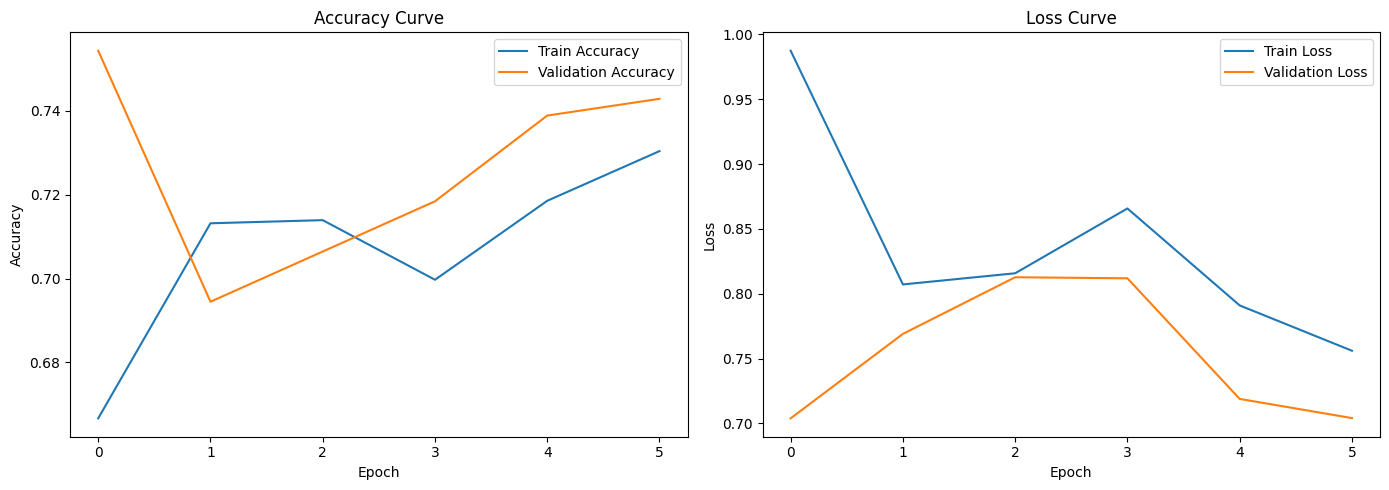

In [13]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
test_generator.reset()

y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

63/63 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step


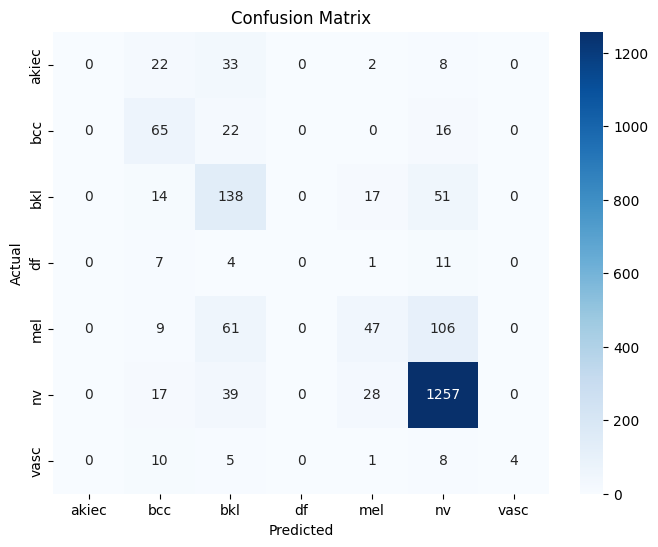

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


Classification Report:

              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        65
         bcc       0.45      0.63      0.53       103
         bkl       0.46      0.63      0.53       220
          df       0.00      0.00      0.00        23
         mel       0.49      0.21      0.29       223
          nv       0.86      0.94      0.90      1341
        vasc       1.00      0.14      0.25        28

    accuracy                           0.75      2003
   macro avg       0.47      0.36      0.36      2003
weighted avg       0.72      0.75      0.72      2003



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
from sklearn.metrics import f1_score
f1_macro = f1_score(
    y_true,
    y_pred,
    average='macro'
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print(f"\nMacro F1 Score    : {f1_macro:.4f}")
print(f"Weighted F1 Score : {f1_weighted:.4f}")


Macro F1 Score    : 0.3569
Weighted F1 Score : 0.7230


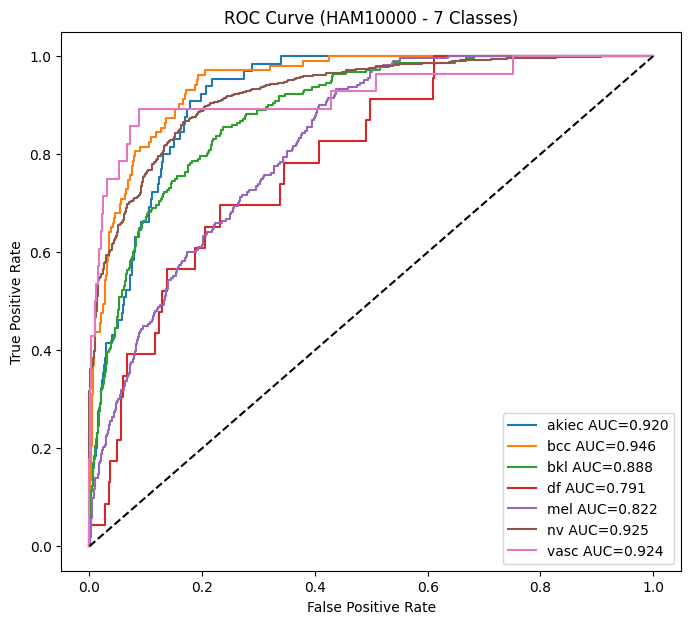

In [25]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

plt.figure(figsize=(8,7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{class_names[i]} AUC={roc_auc:.3f}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (HAM10000 - 7 Classes)")
plt.legend()
plt.show()

In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(class_names)

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(n_classes)
)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

In [24]:
print("AUC Values\n")

for i in range(len(class_names)):
    print(
        class_names[i],
        ":",
        round(roc_auc[i], 4)
    )

AUC Values

akiec : 0.9204
bcc : 0.9465
bkl : 0.8884
df : 0.7907
mel : 0.8223
nv : 0.9251
vasc : 0.9236


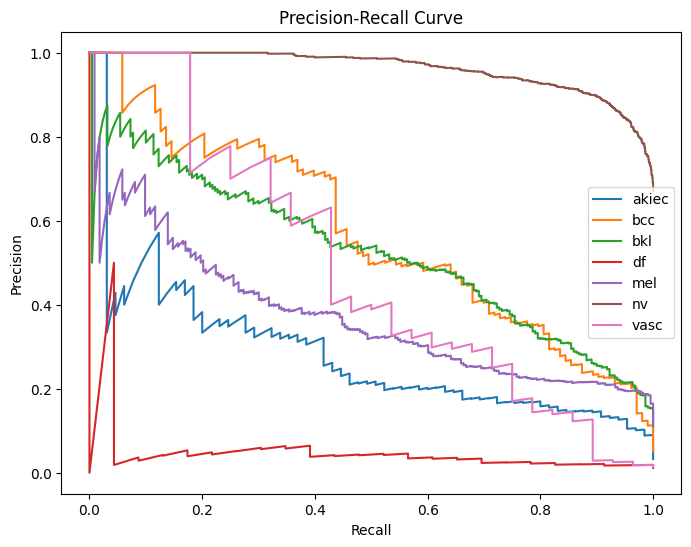

In [19]:
plt.figure(figsize=(8,6))

for i in range(num_classes):

    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=class_names[i]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

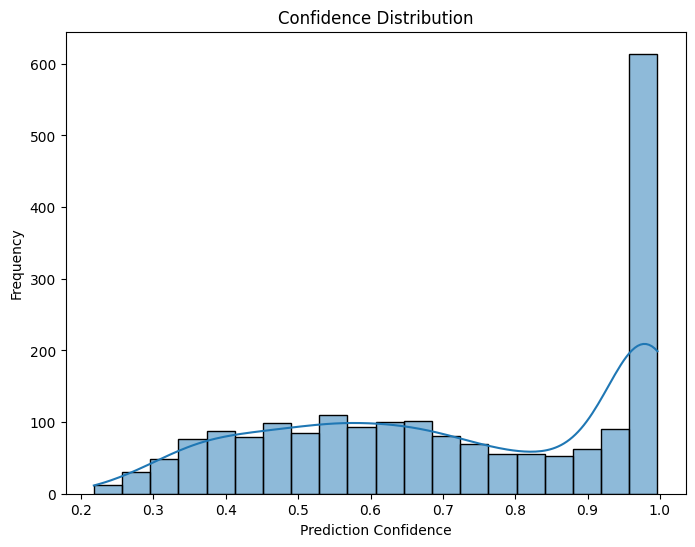

In [20]:
confidence_scores = np.max(
    y_pred_prob,
    axis=1
)

plt.figure(figsize=(8,6))

sns.histplot(
    confidence_scores,
    bins=20,
    kde=True
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution")
plt.show()

In [22]:
print("AUC Values")

for i in range(len(class_names)):
    print(
        class_names[i],
        ":",
        round(roc_auc[i],4)
    )

AUC Values


IndexError: invalid index to scalar variable.